In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

In [2]:
df = pd.read_csv('../data/raw/sentiment-emotion-labelled_Dell_tweets.csv')
#Cancello prima colonna
df.drop(columns=df.columns[0], axis = 1, inplace=True)
print(f"Dimensioni: {df.shape[0]} righe, {df.shape[1]} colonne\n")
print(f"\nColonne presenti:")
print(df.columns.tolist())
print(f"\nTipi di dato:")
print(df.dtypes)
print(f"\nPrime 5 righe:")
df.head()

Dimensioni: 24970 righe, 8 colonne


Colonne presenti:
['Datetime', 'Tweet Id', 'Text', 'Username', 'sentiment', 'sentiment_score', 'emotion', 'emotion_score']

Tipi di dato:
Datetime            object
Tweet Id             int64
Text                object
Username            object
sentiment           object
sentiment_score    float64
emotion             object
emotion_score      float64
dtype: object

Prime 5 righe:


,Datetime,Tweet Id,Text,Username,sentiment,sentiment_score,emotion,emotion_score
0,2022-09-30 23:29:15+00:00,1575991191170342912,@Logitech @apple @Google @Microsoft @Dell @Len...,ManjuSreedaran,neutral,0.853283,anticipation,0.587121
1,2022-09-30 21:46:35+00:00,1575965354425131008,@MK_habit_addict @official_stier @MortalKombat...,MiKeMcDnet,neutral,0.519470,joy,0.886913
2,2022-09-30 21:18:02+00:00,1575958171423752203,"As @CRN celebrates its 40th anniversary, Bob F...",jfollett,positive,0.763791,joy,0.960347
3,2022-09-30 20:05:24+00:00,1575939891485032450,@dell your customer service is horrible especi...,daveccarr,negative,0.954023,anger,0.983203
4,2022-09-30 20:03:17+00:00,1575939359160750080,@zacokalo @Dell @DellCares @Dell give the man ...,heycamella,neutral,0.529170,anger,0.776124


Valutazione dei NaN e Tweet duplicati

In [3]:
#Valori null
print("VALORI MANCANTI:")
print(df.isnull().sum())

if df.isnull().sum().sum() == 0:
    print("\nNessun valore mancante!")

#Duplicati
print("\nDUPLICATI:")
print(f"Righe duplicate: {df.duplicated().sum()}")
print(f"Tweet duplicati (stesso testo): {df['Text'].duplicated().sum()}")
print(f"Tweet ID duplicati: {df['Tweet Id'].duplicated().sum()}")

# Mostra esempi di duplicati
if df['Text'].duplicated().sum() > 0:
    print("\n Esempi di tweet duplicati:")
    dup_mask = df['Text'].duplicated(keep=False)
    print(df[dup_mask][['Text', 'sentiment', 'emotion']].head(6))

#I duplicati vengono rimossi per evitare overfitting
print("\nRIMOZIONE DUPLICATI")

#Rimozione duplicati basata sul testo
df_clean = df.drop_duplicates(subset='Text', keep='first')

# Statistiche dopo la rimozione
print(f"Dataset dopo rimozione duplicati: {len(df_clean)} righe")
print(f"Righe rimosse: {len(df) - len(df_clean)}")
print(f"Percentuale dati mantenuti: {len(df_clean)/len(df)*100:.2f}%")

print(f"Verifica: Tweet duplicati rimasti: {df_clean['Text'].duplicated().sum()}")

df = df_clean

VALORI MANCANTI:
Datetime           0
Tweet Id           0
Text               0
Username           0
sentiment          0
sentiment_score    0
emotion            0
emotion_score      0
dtype: int64

Nessun valore mancante!

DUPLICATI:
Righe duplicate: 0
Tweet duplicati (stesso testo): 331
Tweet ID duplicati: 0

 Esempi di tweet duplicati:
                                                  Text sentiment  emotion
32   @ashu_k7 @Dell Pathetic!!!!! I Dont mind takin...  negative    anger
36   @ashu_k7 @Dell Pathetic!!!!! I Dont mind takin...  negative    anger
68                             @Dell That’s very great  positive      joy
154                              @Dell This is amazing  positive      joy
269             @Dell Bad product Dell Inspiron laptop  negative  disgust
270             @Dell Bad product Dell Inspiron laptop  negative  disgust

RIMOZIONE DUPLICATI
Dataset dopo rimozione duplicati: 24639 righe
Righe rimosse: 331
Percentuale dati mantenuti: 98.67%
Verifica: Tweet dupl

Grafico a torta per distribuzione dei Sentiment

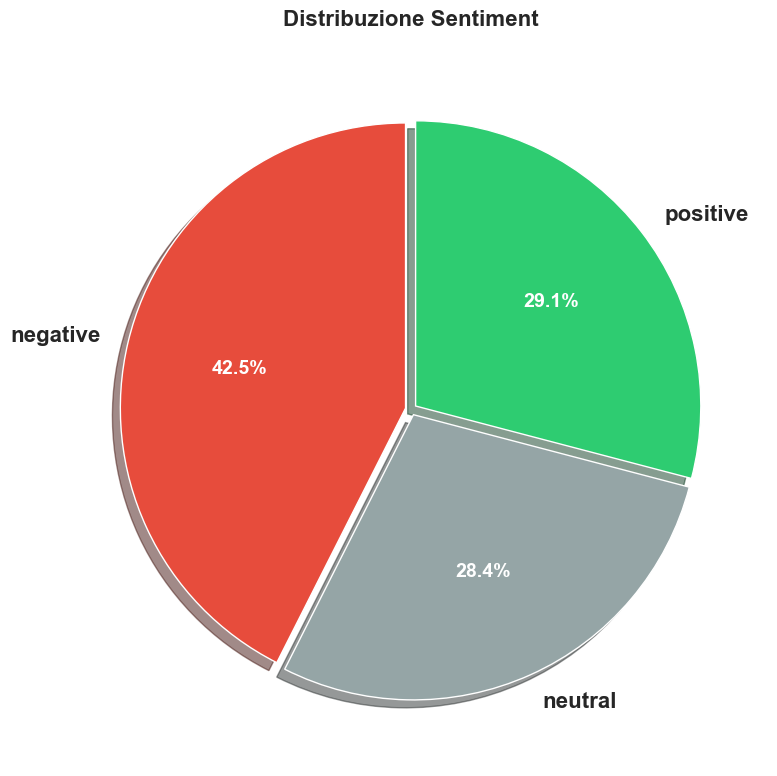

In [4]:
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.2)

sentiment_order = ['negative', 'neutral', 'positive']
sentiment_counts = df['sentiment'].value_counts().reindex(sentiment_order)


colors = ['#e74c3c', '#95a5a6', '#2ecc71']

fig, ax = plt.subplots(figsize=(10, 8))

# Creazione il grafico con esplosione 
explode = (0.02, 0.02, 0.02)  

wedges, texts, autotexts = ax.pie(
    sentiment_counts.values,
    labels=sentiment_counts.index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    explode=explode,
    shadow=True,  
    textprops={'fontsize': 13, 'weight': 'bold'}
)

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(14)
    autotext.set_weight('bold')

for text in texts:
    text.set_fontsize(16)
    text.set_weight('bold')

ax.set_title('Distribuzione Sentiment', fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

Grafico a barre per le emozioni

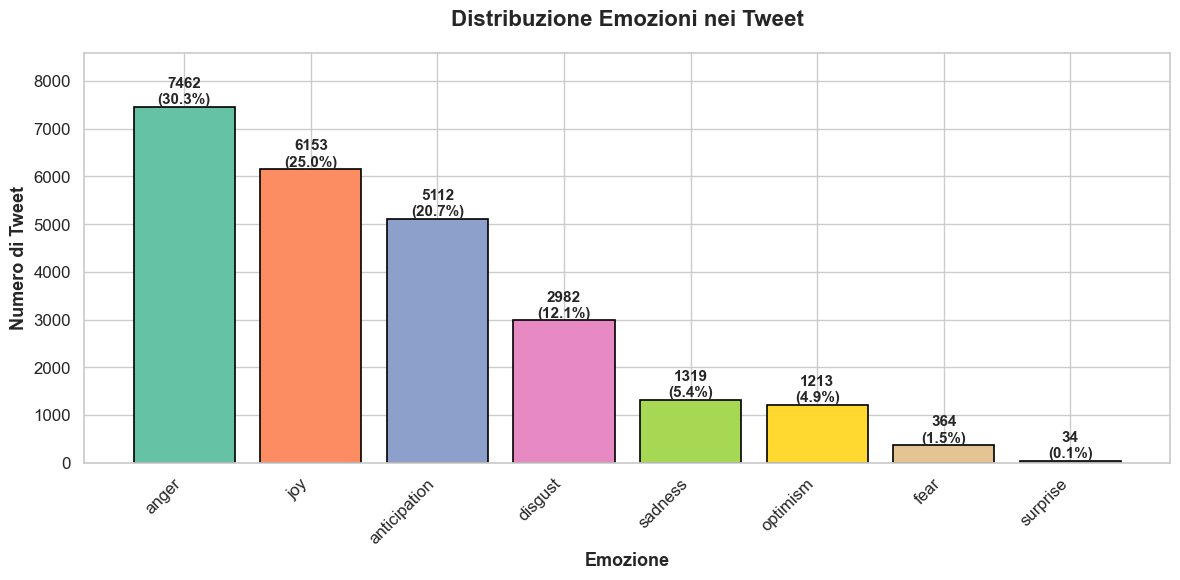

In [5]:
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.1)

emotion_counts = df['emotion'].value_counts()

# Creazione grafico
fig, ax = plt.subplots(figsize=(12, 6))

colors = sns.color_palette("Set2", len(emotion_counts))

bars = ax.bar(emotion_counts.index, emotion_counts.values, color=colors, edgecolor='black', linewidth=1.2)

# Aggiunti i valori sopra le barre
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}\n({height/len(df)*100:.1f}%)',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title('Distribuzione Emozioni nei Tweet', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Emozione', fontsize=13, fontweight='bold')
ax.set_ylabel('Numero di Tweet', fontsize=13, fontweight='bold')
ax.set_ylim(0, max(emotion_counts.values) * 1.15) 
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Grafico a barre per distribuzione delle emozioni per sentiment

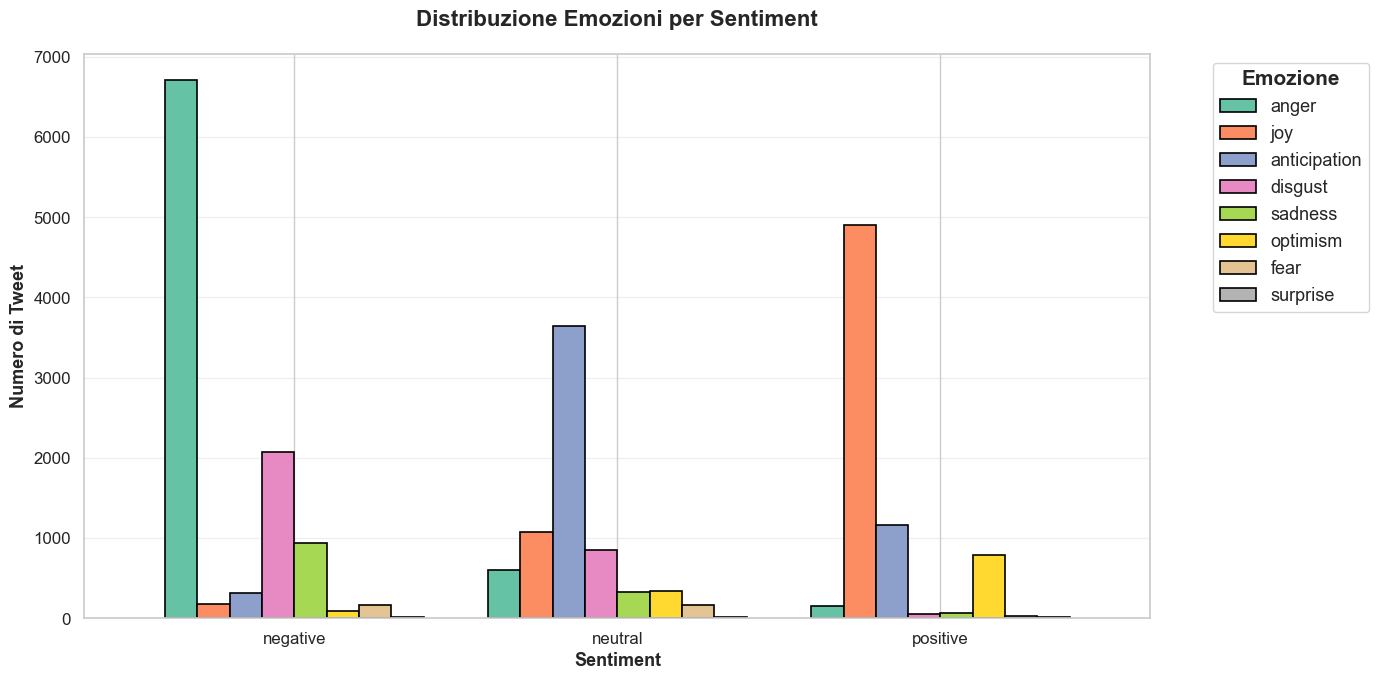

In [6]:
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.1)

emotion_by_sentiment = pd.crosstab(df['sentiment'], df['emotion'])
emotion_by_sentiment = emotion_by_sentiment.reindex(['negative', 'neutral', 'positive'])

#Stesso ordine di prima per mantenere stessi colori
emotion_order = df['emotion'].value_counts().index.tolist()
emotion_by_sentiment = emotion_by_sentiment[emotion_order]

colors = sns.color_palette("Set2", len(emotion_by_sentiment.columns))

fig, ax = plt.subplots(figsize=(14, 7))

emotion_by_sentiment.plot(kind='bar', ax=ax, width=0.8, color=colors, edgecolor='black', linewidth=1.2)

ax.set_title('Distribuzione Emozioni per Sentiment', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Sentiment', fontsize=13, fontweight='bold')
ax.set_ylabel('Numero di Tweet', fontsize=13, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
legend = ax.legend(title='Emozione', bbox_to_anchor=(1.05, 1), loc='upper left', 
                   fontsize=13, title_fontsize=15)
legend.get_title().set_fontweight('bold')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Funzione di preprocessing che fa tokenizzazione: elimina le menzioni, toglie #, elimina i link e converte le emoji

In [7]:
import emoji
from nltk.tokenize import TweetTokenizer
import string

def preprocess_for_word2vec(text):

    #Conversione emoji
    text = emoji.demojize(text, delimiters=(" ", " "))
    
    #Tokenizzazione
    tknzr = TweetTokenizer(preserve_case=False, reduce_len=True)
    tokens = tknzr.tokenize(text)
    
    #Filtraggio
    cleaned_tokens = []
    for token in tokens:
        if token.startswith('@'):
            continue
        if token.startswith('http') or token.startswith('www'):
            continue
        if token.startswith('#'):
            token = token[1:]
            if not token:
                continue
        if token in string.punctuation:
            continue
        if token.isdigit():
            continue
        
        if token.strip():
            cleaned_tokens.append(token)
    
    return cleaned_tokens

Divisione del dataset e applico funzione di tokenizzazione

In [8]:
from sklearn.model_selection import train_test_split

#Split del dataset

target = 'sentiment'

X = df['Text'] 
y = df[target]

print(f"\nTarget: {target}")
print(f"Dataset size: {len(X)}")
print(f"\nDistribuzione classi:")
print(y.value_counts())
print()

#Test set
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.15,
    random_state=42,
    stratify=y
)

#Train set e validation set
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.176,  # 0.176 * 0.85 ≈ 0.15 del totale
    random_state=42,
    stratify=y_temp
)

print(f"Split completato:")
print(f"  Train:      {len(X_train)} tweet ({len(X_train)/len(X)*100:.1f}%)")
print(f"  Validation: {len(X_val)} tweet ({len(X_val)/len(X)*100:.1f}%)")
print(f"  Test:       {len(X_test)} tweet ({len(X_test)/len(X)*100:.1f}%)")
print(f"  Totale:     {len(X_train) + len(X_val) + len(X_test)} tweet")

print(f"\nDistribuzione classi nei set:")
print(f"\nTrain:")
print(y_train.value_counts(normalize=True) * 100)
print(f"\nValidation:")
print(y_val.value_counts(normalize=True) * 100)
print(f"\nTest:")
print(y_test.value_counts(normalize=True) * 100)

#Applicazione della tokenizzazione
print("\nPreprocessing train set...")
X_train_tokens = X_train.apply(preprocess_for_word2vec)

print("Preprocessing validation set...")
X_val_tokens = X_val.apply(preprocess_for_word2vec)

print("Preprocessing test set...")
X_test_tokens = X_test.apply(preprocess_for_word2vec)


train_lengths = X_train_tokens.apply(len)
val_lengths = X_val_tokens.apply(len)
test_lengths = X_test_tokens.apply(len)

print(f"\nStatistiche token:")
print(f"  Train:      media={train_lengths.mean():.2f}, min={train_lengths.min()}, max={train_lengths.max()}")
print(f"  Validation: media={val_lengths.mean():.2f}, min={val_lengths.min()}, max={val_lengths.max()}")
print(f"  Test:       media={test_lengths.mean():.2f}, min={test_lengths.min()}, max={test_lengths.max()}")

#Controlla tweet vuoti
print(f"\nTweet vuoti:")
print(f"  Train:      {(train_lengths == 0).sum()}")
print(f"  Validation: {(val_lengths == 0).sum()}")
print(f"  Test:       {(test_lengths == 0).sum()}")

#Esempi
print("ESEMPI PREPROCESSING (Train set)")

for i in range(3):
    idx = X_train_tokens.index[i]
    print(f"\n{i+1}. Sentiment: {y_train.iloc[i]}")
    print(f"   Originale ({len(X_train.iloc[i])} char):")
    print(f"   {X_train.iloc[i][:80]}...")
    print(f"   Tokens ({len(X_train_tokens.iloc[i])}):")
    print(f"   {X_train_tokens.iloc[i][:12]}...")



Target: sentiment
Dataset size: 24639

Distribuzione classi:
sentiment
negative    10483
positive     7167
neutral      6989
Name: count, dtype: int64

Split completato:
  Train:      17257 tweet (70.0%)
  Validation: 3686 tweet (15.0%)
  Test:       3696 tweet (15.0%)
  Totale:     24639 tweet

Distribuzione classi nei set:

Train:
sentiment
negative    42.545054
positive    29.089645
neutral     28.365301
Name: proportion, dtype: float64

Validation:
sentiment
negative    42.539338
positive    29.083017
neutral     28.377645
Name: proportion, dtype: float64

Test:
sentiment
negative    42.559524
positive    29.085498
neutral     28.354978
Name: proportion, dtype: float64

Preprocessing train set...
Preprocessing validation set...
Preprocessing test set...

Statistiche token:
  Train:      media=23.17, min=1, max=70
  Validation: media=23.21, min=1, max=60
  Test:       media=23.20, min=1, max=63

Tweet vuoti:
  Train:      0
  Validation: 0
  Test:       0
ESEMPI PREPROCESSING (Trai

Train di Word2Vec

In [9]:
from gensim.models import Word2Vec
import time

tokenized_tweets = X_train_tokens.tolist()

print(f"\nParametri Word2Vec:")
print(f"  Documenti training: {len(tokenized_tweets)}")
print(f"  Vector size: 200 dimensioni")
print(f"  Window: 3 parole contesto")
print(f"  Min count: 3 occorrenze minime")

# Train Word2Vec
print("\nTraining in corso...")
start_time = time.time()

w2v_model = Word2Vec(
    sentences=tokenized_tweets,   
    vector_size=200,               
    window=3,                      
    min_count=3,                  
    workers=4,                     
    sg=1,                         
    epochs=20,                  
    seed=42                      
)

training_time = time.time() - start_time

print(f"\nWord2Vec trained in {training_time:.2f} secondi!")
print(f"  Vocabulary size: {len(w2v_model.wv):,} parole uniche")
print(f"  Vector dimensionality: {w2v_model.wv.vector_size}")



Parametri Word2Vec:
  Documenti training: 17257
  Vector size: 200 dimensioni
  Window: 3 parole contesto
  Min count: 3 occorrenze minime

Training in corso...

Word2Vec trained in 8.16 secondi!
  Vocabulary size: 7,936 parole uniche
  Vector dimensionality: 200


Test per Word2Vec

In [10]:
print("Test Word Embeddings")

# Test similarità semantica
test_words = [
    'good', 'bad', 'love', 'hate', 
    'great', 'terrible', 'dell', 'laptop'
]

print("\nParole simili per semantica:")
for word in test_words:
    if word in w2v_model.wv:
        similar = w2v_model.wv.most_similar(word, topn=5)
        print(f"\n'{word}' -->")
        for sim_word, score in similar:
            print(f"  - {sim_word}: {score:.3f}")
    else:
        print(f"\n'{word}': non nel vocabolario")

# Test emoji convertite
emoji_words = ['smiling_face_with_smiling_eyes', 'enraged_face', 'red_heart']
print("\n\nEmoji convertite:")
for emoji_word in emoji_words:
    if emoji_word in w2v_model.wv:
        similar = w2v_model.wv.most_similar(emoji_word, topn=3)
        print(f"\n'{emoji_word}' -->")
        for sim_word, score in similar:
            print(f"  - {sim_word}: {score:.3f}")
    else:
        print(f"  '{emoji_word}': non trovata")

Test Word Embeddings

Parole simili per semantica:

'good' -->
  - glorious: 0.447
  - promising: 0.446
  - desirable: 0.433
  - surprising: 0.425
  - attractive: 0.417

'bad' -->
  - unsatisfactory: 0.570
  - appealing: 0.565
  - shocking: 0.534
  - weak: 0.530
  - shoddy: 0.528

'love' -->
  - wonderful: 0.508
  - grinning_face_with_big_eyes: 0.496
  - ummm: 0.494
  - rich: 0.492
  - cute: 0.489

'hate' -->
  - repetitive: 0.583
  - numpads: 0.579
  - accidentally: 0.576
  - sick: 0.575
  - commercials: 0.574

'great' -->
  - wonderful: 0.533
  - amazing: 0.523
  - fantastic: 0.507
  - nice: 0.483
  - stressful: 0.472

'terrible' -->
  - shoddy: 0.631
  - hopeless: 0.620
  - shocking: 0.606
  - awful: 0.604
  - horrible: 0.594

'dell' -->
  - delllaptop: 0.484
  - amd-powered: 0.462
  - dead.the: 0.457
  - specially: 0.455
  - trades: 0.452

'laptop' -->
  - 3120s: 0.539
  - inspirion: 0.524
  - 3yrs: 0.519
  - dellinspiron: 0.517
  - frozen: 0.504


Emoji convertite:

'smiling_face_

Conversione dei tweet in vettori

In [11]:

def tweet_to_vector(tokens, model):
    """Media dei word embeddings"""
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    
    if vectors:
        return np.mean(vectors, axis=0)
    else:
        return np.zeros(model.wv.vector_size)

X_train_w2v = np.array([tweet_to_vector(tokens, w2v_model) 
                        for tokens in X_train_tokens])

X_val_w2v = np.array([tweet_to_vector(tokens, w2v_model) 
                      for tokens in X_val_tokens])

X_test_w2v = np.array([tweet_to_vector(tokens, w2v_model) 
                       for tokens in X_test_tokens])

print(f"\nConversione completata!")
print(f"  X_train shape: {X_train_w2v.shape}")
print(f"  X_val shape:   {X_val_w2v.shape}")
print(f"  X_test shape:  {X_test_w2v.shape}")

train_coverage = np.count_nonzero(X_train_w2v.sum(axis=1))
val_coverage = np.count_nonzero(X_val_w2v.sum(axis=1))
test_coverage = np.count_nonzero(X_test_w2v.sum(axis=1))

print(f"\nCoverage (tweet con più di 1 parola nel vocabolario):")
print(f"  Train: {train_coverage}/{len(X_train_w2v)} ({train_coverage/len(X_train_w2v)*100:.1f}%)")
print(f"  Val:   {val_coverage}/{len(X_val_w2v)} ({val_coverage/len(X_val_w2v)*100:.1f}%)")
print(f"  Test:  {test_coverage}/{len(X_test_w2v)} ({test_coverage/len(X_test_w2v)*100:.1f}%)")


Conversione completata!
  X_train shape: (17257, 200)
  X_val shape:   (3686, 200)
  X_test shape:  (3696, 200)

Coverage (tweet con più di 1 parola nel vocabolario):
  Train: 17192/17257 (99.6%)
  Val:   3668/3686 (99.5%)
  Test:  3685/3696 (99.7%)


Training del classificatore LogisticRegression

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import time

print("\nModello: Logistic Regression")
clf = LogisticRegression(
    max_iter=1000,
    random_state=42,
    solver='lbfgs',
    C=1.0
)

print("Training in corso...")
start_time = time.time()
clf.fit(X_train_w2v, y_train)
training_time = time.time() - start_time

print(f"Training completato in {training_time:.2f} secondi")


y_pred_val = clf.predict(X_val_w2v)
y_pred_test = clf.predict(X_test_w2v)

val_acc = accuracy_score(y_val, y_pred_val)
test_acc = accuracy_score(y_test, y_pred_test)

print(f"\nACCURACY:")
print(f"  Validation: {val_acc:.4f} ({val_acc*100:.2f}%)")
print(f"  Test:       {test_acc:.4f} ({test_acc*100:.2f}%)")


#Classification Report sul VALIDATION set
print("CLASSIFICATION REPORT (Validation Set)")
print(classification_report(y_val, y_pred_val))

#Confusion Matrix sul VALIDATION set
print("CONFUSION MATRIX (Validation Set)")
cm_val = confusion_matrix(y_val, y_pred_val)
print(cm_val)


Modello: Logistic Regression
Training in corso...
Training completato in 1.34 secondi

ACCURACY:
  Validation: 0.7230 (72.30%)
  Test:       0.7189 (71.89%)
CLASSIFICATION REPORT (Validation Set)
              precision    recall  f1-score   support

    negative       0.76      0.88      0.82      1568
     neutral       0.63      0.50      0.55      1046
    positive       0.73      0.72      0.72      1072

    accuracy                           0.72      3686
   macro avg       0.71      0.70      0.70      3686
weighted avg       0.71      0.72      0.72      3686

CONFUSION MATRIX (Validation Set)
[[1373  127   68]
 [ 307  520  219]
 [ 117  183  772]]


Training del classificatore SVM

In [13]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import time

print("\nModello: SVM con kernel RBF")
clf_svm = SVC(
    kernel='rbf',        
    C=1.0,              
    gamma='scale',     
    class_weight='balanced',
    random_state=42
)

print("Training in corso...")
start_time = time.time()
clf_svm.fit(X_train_w2v, y_train)
training_time = time.time() - start_time

print(f"Training completato in {training_time:.2f} secondi")

y_pred_val = clf_svm.predict(X_val_w2v)
y_pred_test = clf_svm.predict(X_test_w2v)

# Accuracy
val_acc = accuracy_score(y_val, y_pred_val)
test_acc = accuracy_score(y_test, y_pred_test)

print(f"\nACCURACY:")
print(f"  Validation: {val_acc:.4f} ({val_acc*100:.2f}%)")
print(f"  Test:       {test_acc:.4f} ({test_acc*100:.2f}%)")

#Classification Report sul VALIDATION set
print("CLASSIFICATION REPORT (Validation Set)")
print(classification_report(y_val, y_pred_val))

#Confusion Matrix sul VALIDATION set
print("CONFUSION MATRIX (Validation Set)")
cm_val = confusion_matrix(y_val, y_pred_val)
print(cm_val)


Modello: SVM con kernel RBF
Training in corso...
Training completato in 40.56 secondi

ACCURACY:
  Validation: 0.7580 (75.80%)
  Test:       0.7630 (76.30%)
CLASSIFICATION REPORT (Validation Set)
              precision    recall  f1-score   support

    negative       0.82      0.85      0.83      1568
     neutral       0.66      0.62      0.64      1046
    positive       0.75      0.76      0.76      1072

    accuracy                           0.76      3686
   macro avg       0.74      0.74      0.74      3686
weighted avg       0.76      0.76      0.76      3686

CONFUSION MATRIX (Validation Set)
[[1325  157   86]
 [ 208  652  186]
 [  78  177  817]]


Training della rete LSTM

In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix


# Preparazione dei dati in un dizionario
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_val_enc = le.transform(y_val)
y_test_enc = le.transform(y_test)

word2idx = {w: i+1 for i, w in enumerate(w2v_model.wv.index_to_key)}
vocab_size = len(word2idx) + 1


def to_seq(tokens_list, max_len=50):
    seqs = [[word2idx.get(w, 0) for w in tokens] for tokens in tokens_list]
    return pad_sequences(seqs, maxlen=max_len, padding='post')


X_train_seq = to_seq(X_train_tokens)
X_val_seq = to_seq(X_val_tokens)
X_test_seq = to_seq(X_test_tokens) 


# Matrice di embedding usando Word2Vec
emb_dim = 200
emb_matrix = np.zeros((vocab_size, emb_dim))
for word, idx in word2idx.items():
    if word in w2v_model.wv:
        emb_matrix[idx] = w2v_model.wv[word]


# Modello con Dropout per ridurre overfitting
model = Sequential([
    Embedding(vocab_size, emb_dim, weights=[emb_matrix]),
    Dropout(0.3),
    LSTM(128, dropout=0.2, recurrent_dropout=0.2),
    Dropout(0.5),
    Dense(3, activation='softmax')
])


model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


# Callbacks: Early Stopping e Model Checkpoint
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        'best_lstm_model.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )
]

# Training
print("Inizio training...")
history = model.fit(
    X_train_seq, y_train_enc,
    validation_data=(X_val_seq, y_val_enc),
    epochs=20,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)

# Validation (per riferimento)
val_loss, val_acc = model.evaluate(X_val_seq, y_val_enc, verbose=0)
print(f"\nValidation Accuracy: {val_acc*100:.2f}%")
print(f"Validation Loss: {val_loss:.4f}")

# Valutazione finale sul test set
print("\nVALUTAZIONE FINALE SUL TEST SET")
test_loss, test_acc = model.evaluate(X_test_seq, y_test_enc, verbose=0)
print(f"Test Accuracy: {test_acc*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")


# Predizioni sul test set
y_pred = model.predict(X_test_seq, verbose=0)
y_pred_classes = np.argmax(y_pred, axis=1)


# Report dettagliato
print("\nClassification Report:")
print(classification_report(y_test_enc, y_pred_classes, target_names=le.classes_))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_enc, y_pred_classes))


Inizio training...
Epoch 1/20
270/270 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.5263 - loss: 0.9349
Epoch 1: val_loss improved from None to 0.70204, saving model to best_lstm_model.keras

Epoch 1: finished saving model to best_lstm_model.keras
270/270 ━━━━━━━━━━━━━━━━━━━━ 20s 66ms/step - accuracy: 0.5923 - loss: 0.8526 - val_accuracy: 0.6891 - val_loss: 0.7020
Epoch 2/20
270/270 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.6636 - loss: 0.7545
Epoch 2: val_loss improved from 0.70204 to 0.65557, saving model to best_lstm_model.keras

Epoch 2: finished saving model to best_lstm_model.keras
270/270 ━━━━━━━━━━━━━━━━━━━━ 17s 63ms/step - accuracy: 0.6801 - loss: 0.7414 - val_accuracy: 0.7393 - val_loss: 0.6556
Epoch 3/20
270/270 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.7211 - loss: 0.6820
Epoch 3: val_loss improved from 0.65557 to 0.59813, saving model to best_lstm_model.keras

Epoch 3: finished saving model to best_lstm_model.keras
270/270 ━━━━━━━━━━━━━━━━━━━━ 18s 68ms/step -

WordCloud


1. Preprocessing tweets...
  ✓ Processed 24,639 tweets
  Average tokens before: 26.9
  Average tokens after:  11.9
  Reduction: 55.5%

  Example:
    Original: @Logitech @apple @Google @Microsoft @Dell @Lenovo #WhatIf QWERTY were modified for programmers so things like brackets, parens, quotes, operators, etc. moved to the middle near G-H splitting left/right brackets to separate hands, and relieving the less dextrous pinky finger?
    Tokens:   ['whatif', 'qwerty', 'modified', 'programmers', 'brackets', 'parens', 'quotes', 'operators', 'moved', 'middle', 'near', 'g-h', 'splitting', 'left', 'right', 'brackets', 'separate', 'hands', 'relieving', 'less', 'dextrous', 'pinky', 'finger']
    Cleaned:  whatif qwerty modified programmers brackets parens quotes operators moved middle near g-h splitting left right brackets separate hands relieving less dextrous pinky finger
  Negative  : 10,483 tweets
  Neutral   :  6,989 tweets
  Positive  :  7,167 tweets
  → negative...
  → neutral...
  → po

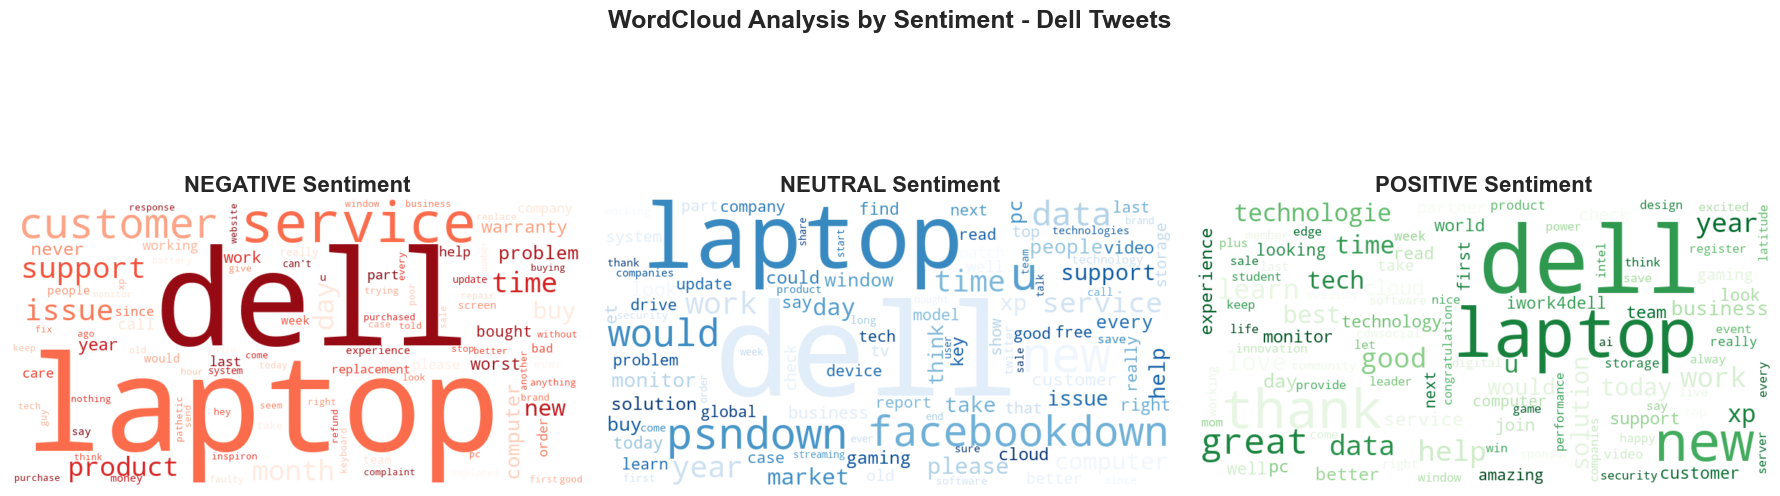

In [ ]:
import pandas as pd
import emoji
from nltk.tokenize import TweetTokenizer
from nltk.corpus import stopwords
import string
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt
from collections import Counter


def preprocess_for_wordcloud(text):
    """
    Preprocessing AGGRESSIVO per WordCloud
    - Rimuove emoji (non converte)
    - Rimuove stopwords
    - Rimuove mentions, URL, hashtag, numeri
    - Mantiene solo parole significative
    """
    #Rimozione emoji
    text = emoji.replace_emoji(text, replace='')
    
    #Tokenizzazione
    tknzr = TweetTokenizer(preserve_case=False, reduce_len=True)
    tokens = tknzr.tokenize(text)
    
    #Caricamento stop words inglesi
    stop_words = set(stopwords.words('english'))
    
    #Aggiunta stop words custom
    custom_stopwords = {
        'rt', 'via', 'retweet', 'retweeted',
        'get', 'got', 'getting',
        'go', 'going', 'goes', 'gone',
        'use', 'using', 'used', 'uses',
        'make', 'makes', 'making', 'made',
        'want', 'wanted', 'wants',
        'need', 'needs', 'needed',
        'know', 'knows', 'known',
        'thing', 'things',
        'like', 'likes', 'liked',
        'see', 'seen', 'saw',
        'one', 'two', 'also', 'much', 'many',
        'even', 'back', 'still', 'way', 'etc.', 'etc'
    }
    
    stop_words.update(custom_stopwords)
    
    #Filtraggio
    cleaned_tokens = []
    for token in tokens:
        #Rimozione mentions
        if token.startswith('@'):
            continue
        
        #Rimozione URL
        if token.startswith('http') or token.startswith('www'):
            continue
        
        #Rimozione # dagli hashtag 
        if token.startswith('#'):
            token = token[1:]  
            if not token:      
                continue
        
        #Rimozione punteggiatura
        if token in string.punctuation:
            continue
        
        #Rimozione numeri
        if token.isdigit():
            continue
        
        #Rimozione stopwords 
        if token.lower() in stop_words:
            continue
        
        if token.strip():
            cleaned_tokens.append(token)
    
    return cleaned_tokens


print("\n1. Preprocessing tweets...")

df['tokens'] = df['Text'].apply(preprocess_for_wordcloud)

df['cleaned_text'] = df['tokens'].apply(lambda x: ' '.join(x))

avg_tokens_before = df['Text'].str.split().str.len().mean()
avg_tokens_after = df['tokens'].str.len().mean()

print(f"  ✓ Processed {len(df):,} tweets")
print(f"  Average tokens before: {avg_tokens_before:.1f}")
print(f"  Average tokens after:  {avg_tokens_after:.1f}")
print(f"  Reduction: {((avg_tokens_before - avg_tokens_after) / avg_tokens_before * 100):.1f}%")

print(f"\n  Example:")
print(f"    Original: {df['Text'].iloc[0]}")
print(f"    Tokens:   {df['tokens'].iloc[0]}")
print(f"    Cleaned:  {df['cleaned_text'].iloc[0]}")

#Raggruppa per sentiment
texts_by_sentiment = {
    'negative': [],
    'neutral': [],
    'positive': []
}

for sentiment in ['negative', 'neutral', 'positive']:
    tweets = df[df['sentiment'] == sentiment]['cleaned_text'].tolist()
    texts_by_sentiment[sentiment] = tweets
    print(f"  {sentiment.capitalize():<10}: {len(tweets):>6,} tweets")

#Creazione delle wordcloud
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sentiment_config = {
    'negative': {'colormap': 'Reds', 'title': 'NEGATIVE'},
    'neutral': {'colormap': 'Blues', 'title': 'NEUTRAL'},
    'positive': {'colormap': 'Greens', 'title': 'POSITIVE'}
}

for idx, sentiment in enumerate(['negative', 'neutral', 'positive']):
    print(f"  → {sentiment}...")
    
    # Unisci tweet del sentiment
    text = ' '.join(texts_by_sentiment[sentiment])
    
    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white',
        stopwords=set(), 
        colormap=sentiment_config[sentiment]['colormap'],
        max_words=100,
        relative_scaling=0.5,
        min_font_size=10,
        collocations=False
    ).generate(text)
    
    axes[idx].imshow(wordcloud, interpolation='bilinear')
    axes[idx].axis('off')
    axes[idx].set_title(
        f"{sentiment_config[sentiment]['title']} Sentiment",
        fontsize=16,
        fontweight='bold'
    )

plt.suptitle('WordCloud Analysis by Sentiment - Dell Tweets',
             fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\matte\AppData\Roaming\nltk_data...


WORDCLOUD WITH SENTIMENT-FILTERED WORDS

1. Loading sentiment analyzer...
  ✓ Sentiment analyzer ready

2. Filtering words by sentiment...

  Processing negative tweets...
    Words before: 145,712
    Words after:  10,638
    Reduction:    92.7%

  Processing neutral tweets...
    Words before: 67,539
    Words after:  62,788
    Reduction:    7.0%

  Processing positive tweets...
    Words before: 81,193
    Words after:  9,648
    Reduction:    88.1%

3. Generating sentiment-filtered WordClouds...
  → negative...
  → neutral...
  → positive...

✓ Saved: wordcloud_sentiment_filtered.png


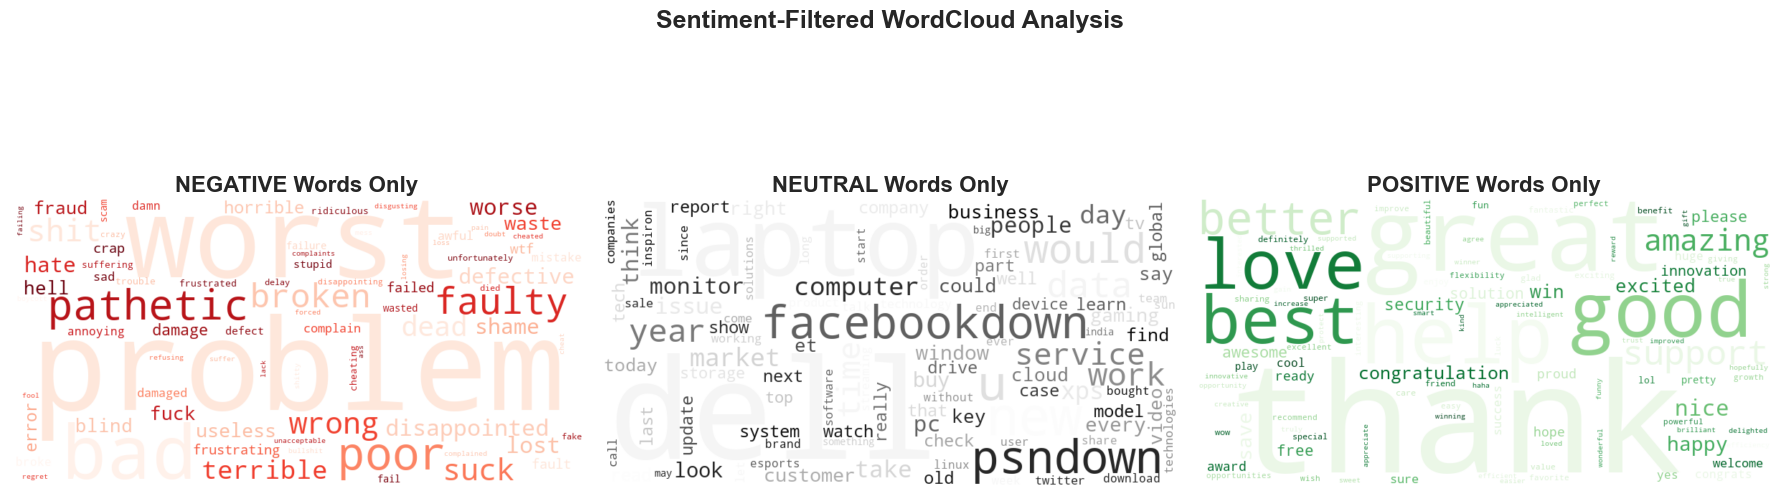


TOP 20 SENTIMENT-COHERENT WORDS

NEGATIVE WORDS:
--------------------------------------------------
   1. worst                  628 times (score: -0.625)
   2. problem                569 times (score: -0.402)
   3. bad                    416 times (score: -0.542)
   4. poor                   253 times (score: -0.477)
   5. pathetic               233 times (score: -0.572)
   6. faulty                 205 times (score: -0.318)
   7. broken                 186 times (score: -0.477)
   8. shit                   171 times (score: -0.557)
   9. wrong                  170 times (score: -0.477)
  10. dead                   158 times (score: -0.649)
  11. terrible               144 times (score: -0.477)
  12. problems               141 times (score: -0.402)
  13. disappointed           128 times (score: -0.477)
  14. lost                   127 times (score: -0.318)
  15. worse                  124 times (score: -0.477)
  16. shame                  122 times (score: -0.477)
  17. sucks        

In [ ]:
from nltk.sentiment import SentimentIntensityAnalyzer
from collections import Counter
import pandas as pd
import nltk
nltk.download('vader_lexicon')

print("="*70)
print("WORDCLOUD WITH SENTIMENT-FILTERED WORDS")
print("="*70)

print("\n1. Loading sentiment analyzer...")



sia = SentimentIntensityAnalyzer()

def get_word_sentiment(word):
    """
    Calcola sentiment di una singola parola
    Returns: 'positive', 'negative', or 'neutral'
    """
    scores = sia.polarity_scores(word)
    
    # Soglie per classificazione
    if scores['compound'] >= 0.3:
        return 'positive'
    elif scores['compound'] <= -0.3:
        return 'negative'
    else:
        return 'neutral'

print("  ✓ Sentiment analyzer ready")

# ============================================================================
# 2. FILTRA PAROLE PER SENTIMENT
# ============================================================================
print("\n2. Filtering words by sentiment...")

# Hai già texts_by_sentiment dal preprocessing precedente
filtered_texts_by_sentiment = {
    'negative': [],
    'neutral': [],
    'positive': []
}

for sentiment in ['negative', 'neutral', 'positive']:
    print(f"\n  Processing {sentiment} tweets...")
    
    # Per ogni tweet del sentiment
    for tweet_text in texts_by_sentiment[sentiment]:
        words = tweet_text.split()
        filtered_words = []
        
        # Filtra parole che matchano il sentiment
        for word in words:
            word_sentiment = get_word_sentiment(word)
            
            if sentiment == 'negative':
                # Mantieni solo parole negative
                if word_sentiment == 'negative':
                    filtered_words.append(word)
            
            elif sentiment == 'positive':
                # Mantieni solo parole positive
                if word_sentiment == 'positive':
                    filtered_words.append(word)
            
            else:  # neutral
                # Mantieni parole neutre E parole non classificate
                if word_sentiment == 'neutral':
                    filtered_words.append(word)
        
        # Aggiungi tweet filtrato
        if filtered_words:  # Solo se ha parole valide
            filtered_texts_by_sentiment[sentiment].append(' '.join(filtered_words))
    
    # Statistiche
    total_words_before = sum(len(t.split()) for t in texts_by_sentiment[sentiment])
    total_words_after = sum(len(t.split()) for t in filtered_texts_by_sentiment[sentiment])
    reduction = ((total_words_before - total_words_after) / total_words_before) * 100
    
    print(f"    Words before: {total_words_before:,}")
    print(f"    Words after:  {total_words_after:,}")
    print(f"    Reduction:    {reduction:.1f}%")

# ============================================================================
# 3. GENERA WORDCLOUD FILTRATE
# ============================================================================
print("\n3. Generating sentiment-filtered WordClouds...")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sentiment_config = {
    'negative': {'colormap': 'Reds', 'title': 'NEGATIVE'},
    'neutral': {'colormap': 'Greys', 'title': 'NEUTRAL'},
    'positive': {'colormap': 'Greens', 'title': 'POSITIVE'}
}

for idx, sentiment in enumerate(['negative', 'neutral', 'positive']):
    print(f"  → {sentiment}...")
    
    # Usa testi FILTRATI
    text = ' '.join(filtered_texts_by_sentiment[sentiment])
    
    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white',
        stopwords=set(),
        colormap=sentiment_config[sentiment]['colormap'],
        max_words=100,
        relative_scaling=1.0,
        min_font_size=10,
        collocations=False,
        random_state=42
    ).generate(text)
    
    axes[idx].imshow(wordcloud, interpolation='bilinear')
    axes[idx].axis('off')
    axes[idx].set_title(
        f"{sentiment_config[sentiment]['title']} Words Only",
        fontsize=16,
        fontweight='bold'
    )

plt.suptitle('Sentiment-Filtered WordCloud Analysis',
             fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ============================================================================
# 4. TOP WORDS (SOLO SENTIMENT-COERENTI)
# ============================================================================
print("\n" + "="*70)
print("TOP 20 SENTIMENT-COHERENT WORDS")
print("="*70)

for sentiment in ['negative', 'neutral', 'positive']:
    all_words = ' '.join(filtered_texts_by_sentiment[sentiment]).split()
    word_counts = Counter(all_words)
    top_20 = word_counts.most_common(20)
    
    print(f"\n{sentiment.upper()} WORDS:")
    print("-" * 50)
    for rank, (word, count) in enumerate(top_20, 1):
        # Mostra sentiment score
        score = sia.polarity_scores(word)['compound']
        print(f"  {rank:2d}. {word:<20} {count:>5,} times (score: {score:+.3f})")

print("\n" + "="*70)
